# Paper Review + Implementation Project
## **Improving Language Understanding by Generative Pre-Training** — GPT-1

This notebook studies the OpenAI paper **“Improving Language Understanding by Generative Pre-Training”** by Radford, Narasimhan, Salimans, and Sutskever.

Our goal is to learn the paper :

1. Understand the research problem and the motivation.
2. Understand the GPT-1 method: input, output, architecture, objective, loss, and data flow.
3. Draw and explain the architecture.
4. Study the mathematics equation by equation.
5. Analyze datasets, baselines, metrics, results, and ablations.
6. Discuss assumptions, limitations, failure points, research gaps, and future directions.
7. Implement a small GPT-style decoder-only Transformer in PyTorch.
8. Build a full project using a scikit-learn text dataset.

> Learning note: this notebook is a **small educational implementation**, not a full reproduction of GPT-1. The original paper used a much larger model, BPE tokenization, BooksCorpus pre-training, and many benchmark datasets. Here we keep the code runnable in a normal Colab/CPU environment.

**Primary paper:** Radford et al., 2018, *Improving Language Understanding by Generative Pre-Training*.

# Big Picture Review

## What problem are the authors solving?

The authors are solving a central problem in natural language understanding:

> Many NLP tasks need labeled datasets, but labeled data is expensive, limited, and task-specific. Meanwhile, unlabeled text is abundant.

Before this paper, many NLP systems were trained mostly in a supervised way for each individual task. That created several problems:

- Each task needed its own labeled data.
- Each task often needed its own model architecture.
- Models did not easily transfer knowledge from one task to another.
- Word embeddings helped, but they mostly transferred word-level information, not deeper sentence-level or discourse-level understanding.

The paper asks:

> Can we train one general language model on unlabeled text first, then adapt it to many supervised language understanding tasks with minimal architecture changes?

## Why is it important?

This idea is important because it created one of the core recipes behind modern large language models:

```text
Large unlabeled text corpus
        ↓
Generative language-model pre-training
        ↓
Task-specific supervised fine-tuning
        ↓
Strong performance on many downstream NLP tasks
```

This recipe is important for research and industry because:

- Unlabeled text is much easier to collect than labeled task data.
- The same pre-trained model can be reused across tasks.
- Fine-tuning becomes cheaper than training a new deep model from scratch.
- The model can learn grammar, semantics, world knowledge, and long-range dependencies during pre-training.
- It reduces dependence on hand-designed task-specific architectures.

## What is their main idea?

The main idea is a **two-stage training framework**:

### Stage 1: Generative pre-training
Train a Transformer decoder language model to predict the next token from previous tokens.

### Stage 2: Discriminative fine-tuning
Adapt the same model to supervised tasks such as classification, entailment, question answering, and semantic similarity.

The model stays mostly the same. The main change is the input format and a small task-specific output layer.

## Main contributions

The paper contributes:

1. A general framework for **unsupervised generative pre-training + supervised fine-tuning**.
2. A decoder-only Transformer language model for transfer learning in NLP.
3. Task-aware input transformations so structured tasks can be converted into token sequences.
4. Strong results across 12 language understanding benchmarks.
5. Evidence that pre-training helps, through ablation studies.
6. Early evidence of zero-shot behavior emerging from generative language modeling.

# Problem Setup in Simple Terms

We have two kinds of data.

## Unlabeled data
A huge text corpus with no labels:

```text
U = {u1, u2, u3, ..., un}
```

Example:

```text
The model learns from raw text without human labels.
```

The model learns by predicting the next token:

```text
Input:  The model learns from raw
Target: model learns from raw text
```

## Labeled data
A smaller task-specific dataset:

```text
C = {(x, y)}
```

Example for text classification:

```text
x = "The team won the final match"
y = "sports"
```

The paper's key idea is to first learn language generally from `U`, then learn the target task from `C`.

# Understand the Method

## Input

The model accepts a sequence of tokens.

For language modeling:

```text
[u1, u2, u3, ..., ut]
```

For text classification:

```text
[start] document tokens [end]
```

For entailment:

```text
[start] premise [delimiter] hypothesis [end]
```

For similarity:

```text
[start] sentence1 [delimiter] sentence2 [end]
[start] sentence2 [delimiter] sentence1 [end]
```

For multiple-choice question answering:

```text
[start] document + question [delimiter] answer_option_k [end]
```

The main trick is that even structured tasks are converted into a **single token sequence**.

## Output

During pre-training:

```text
Output = probability distribution over the next token
```

During fine-tuning:

```text
Output = probability distribution over task labels/classes
```

## Model architecture

The model is a **Transformer decoder-only language model**.

Important components:

- Token embedding
- Learned positional embedding
- Stack of Transformer decoder blocks
- Masked multi-head self-attention
- Feed-forward network
- Residual connections
- Layer normalization
- Linear + softmax output layer

The original GPT-1 model used:

| Component | Paper setting |
|---|---:|
| Architecture | 12-layer decoder-only Transformer |
| Hidden size | 768 |
| Attention heads | 12 |
| Feed-forward inner size | 3072 |
| Context length | 512 tokens |
| Vocabulary | BPE, 40,000 merges |
| Activation | GELU |
| Dropout | 0.1 |
| Position embedding | Learned |
| Optimizer | Adam |

## Training objective

The pre-training objective is next-token prediction.

The fine-tuning objective is supervised classification or task prediction.

The paper also adds an auxiliary language-modeling loss during fine-tuning:

```text
Final fine-tuning objective = supervised objective + λ × language-modeling objective
```

## Data flow

```text
Raw text
  ↓
Tokenizer / BPE
  ↓
Token IDs
  ↓
Token embedding + position embedding
  ↓
Masked self-attention Transformer blocks
  ↓
Final hidden states
  ↓                         ↓
LM head for next token       Classifier head for downstream task
```

# Draw the GPT-1 Architecture

## Text architecture diagram

```text
                         GPT-1 / Decoder-only Transformer

Input text
   ↓
Tokenizer / BPE
   ↓
Token IDs: [x1, x2, x3, ..., xt]
   ↓
Token Embedding + Learned Position Embedding
   ↓
┌─────────────────────────────────────────────┐
│ Transformer Decoder Block 1                 │
│  - Masked Multi-Head Self-Attention         │
│  - Residual + LayerNorm                     │
│  - Feed Forward Network                     │
│  - Residual + LayerNorm                     │
└─────────────────────────────────────────────┘
   ↓
┌─────────────────────────────────────────────┐
│ Transformer Decoder Block 2                 │
└─────────────────────────────────────────────┘
   ↓
                    ...
   ↓
┌─────────────────────────────────────────────┐
│ Transformer Decoder Block N                 │
└─────────────────────────────────────────────┘
   ↓
Final hidden states
   ↓
┌─────────────────────────────┬─────────────────────────────┐
│ Pre-training LM head         │ Fine-tuning classifier head  │
│ Predict next token           │ Predict task label           │
└─────────────────────────────┴─────────────────────────────┘
```

## Why masked attention?

In language modeling, the model must not see future tokens.

For position `t`, the model can attend only to:

```text
x1, x2, ..., xt
```

It cannot attend to:

```text
x(t+1), x(t+2), ...
```

This makes the model autoregressive and suitable for generation.

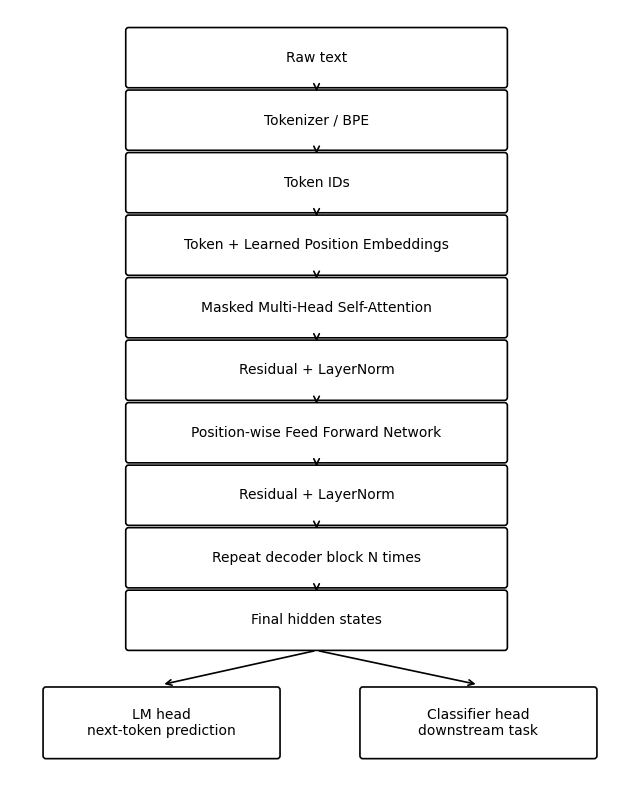

In [1]:
# Architecture diagram drawn with matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


def add_box(ax, xy, text, width=5.5, height=0.75):
    x, y = xy
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.02,rounding_size=0.04",
        linewidth=1.2,
        facecolor="none"
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=10)


def arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", lw=1.2))

fig, ax = plt.subplots(figsize=(8, 10))
ax.axis("off")

items = [
    "Raw text",
    "Tokenizer / BPE",
    "Token IDs",
    "Token + Learned Position Embeddings",
    "Masked Multi-Head Self-Attention",
    "Residual + LayerNorm",
    "Position-wise Feed Forward Network",
    "Residual + LayerNorm",
    "Repeat decoder block N times",
    "Final hidden states",
]

x = 1.2
start_y = 8.8
step = 0.82
for i, item in enumerate(items):
    y = start_y - i * step
    add_box(ax, (x, y), item)
    if i < len(items) - 1:
        arrow(ax, x + 2.75, y, x + 2.75, y - 0.1)

# Output heads
add_box(ax, (0.0, 0.0), "LM head\nnext-token prediction", width=3.4, height=0.9)
add_box(ax, (4.6, 0.0), "Classifier head\ndownstream task", width=3.4, height=0.9)
arrow(ax, x + 2.75, 1.4, 1.7, 0.95)
arrow(ax, x + 2.75, 1.4, 6.3, 0.95)

ax.set_xlim(-0.5, 8.5)
ax.set_ylim(-0.3, 9.8)
plt.show()

# Study the Mathematics

The paper has three central mathematical ideas.

---

## Equation 1: Unsupervised language-model pre-training

\[
L_1(U) = \sum_i \log P(u_i \mid u_{i-k}, ..., u_{i-1}; \Theta)
\]

### What is this equation computing?

It computes the total log-likelihood of predicting each token from its previous context.

For token `ui`, the model receives previous tokens:

```text
u(i-k), ..., u(i-1)
```

Then it predicts:

```text
ui
```

### Why do we need it?

This is how the model learns language without labels. It learns syntax, semantics, facts, and long-range dependencies by solving next-token prediction.

### Where is it used?

It is used during the first stage: **generative pre-training**.

### Variables

| Symbol | Meaning |
|---|---|
| `U` | Unsupervised corpus of tokens |
| `ui` | Current target token |
| `k` | Context window size |
| `Θ` | Model parameters |
| `P(ui | context)` | Probability assigned to the correct next token |

---

## Equation 2: Transformer language model

\[
h_0 = UW_e + W_p
\]

\[
h_l = transformer\_block(h_{l-1}) \quad \forall l \in [1,n]
\]

\[
P(u) = softmax(h_n W_e^T)
\]

### What is this computing?

1. Convert token IDs into vectors using token embeddings.
2. Add learned positional embeddings.
3. Pass the sequence through Transformer decoder blocks.
4. Use softmax to produce probabilities over the vocabulary.

### Why do we need it?

A neural network cannot directly understand token IDs. It needs vector representations. The Transformer blocks then transform those vectors into contextual representations.

### Where is it used?

It is used inside the GPT language model during pre-training and fine-tuning.

### Variables

| Symbol | Meaning |
|---|---|
| `U` | Context token sequence |
| `We` | Token embedding matrix |
| `Wp` | Position embedding matrix |
| `h0` | Initial token + position representation |
| `hl` | Hidden states after layer `l` |
| `n` | Number of Transformer layers |
| `softmax` | Converts logits into probabilities |

---

## Equation 3: Supervised fine-tuning prediction

\[
P(y \mid x^1, ..., x^m) = softmax(h_l^m W_y)
\]

### What is this computing?

It computes the probability of each supervised task label.

For a classification task, the model uses the final hidden representation and maps it to class probabilities.

### Why do we need it?

The pre-trained model learns general language. The classifier head converts that language representation into task-specific predictions.

### Where is it used?

It is used during supervised fine-tuning.

### Variables

| Symbol | Meaning |
|---|---|
| `x1...xm` | Input token sequence |
| `y` | Task label |
| `h_l^m` | Final hidden state at the final token |
| `Wy` | Classifier weight matrix |

---

## Equation 4: Supervised objective

\[
L_2(C) = \sum_{(x,y)} \log P(y \mid x^1, ..., x^m)
\]

This maximizes the probability of the correct label over the supervised dataset `C`.

---

## Equation 5: Fine-tuning with auxiliary LM loss

\[
L_3(C) = L_2(C) + \lambda \times L_1(C)
\]

### What is this computing?

It combines:

1. Supervised task loss.
2. Auxiliary language modeling loss.

### Why do we need it?

The paper found that keeping the LM objective during fine-tuning improves generalization and speeds convergence.

### Where is it used?

It is used during fine-tuning.

### Variables

| Symbol | Meaning |
|---|---|
| `L2(C)` | Supervised task objective |
| `L1(C)` | LM objective applied on supervised examples |
| `λ` | Weight controlling the auxiliary LM loss |

# Paper Experiments

## Datasets used in the paper

The paper evaluates four task families.

| Task family | Datasets |
|---|---|
| Natural language inference | SNLI, MultiNLI, QNLI, RTE, SciTail |
| Question answering / commonsense reasoning | RACE, Story Cloze |
| Semantic similarity | MRPC, QQP, STS-B |
| Classification | SST-2, CoLA |

For unsupervised pre-training, the paper used **BooksCorpus**, which contains over 7,000 unpublished books from several genres. The key reason is that books provide long contiguous text, which helps the language model learn long-range dependency.

## Baselines

The paper compares GPT-1 against strong task-specific models and transfer-learning baselines, including:

- ESIM + ELMo
- CAFE
- Stochastic Answer Network
- GenSen
- Multi-task BiLSTM + attention
- Sparse byte mLSTM
- TF-KLD
- ECNU mixed ensemble
- Transformer without pre-training
- Transformer without auxiliary LM loss
- LSTM with auxiliary LM loss

## Evaluation metrics

Different tasks use different metrics.

| Task | Common metric |
|---|---|
| NLI | Accuracy |
| RACE / Story Cloze | Accuracy |
| SST-2 | Accuracy |
| CoLA | Matthews correlation |
| MRPC / QQP | F1 |
| STS-B | Pearson correlation |
| GLUE | Aggregate benchmark score |

## Main results summary

Important reported results:

- The model improved the state of the art on **9 out of 12** evaluated datasets.
- Story Cloze reached **86.5**.
- RACE overall reached **59.0**.
- CoLA reached **45.4** Matthews correlation.
- SST-2 reached **91.3%** accuracy.
- GLUE score reached **72.8**, compared with the previous best **68.9**.

## Ablation study summary

The paper's ablation table is especially important for interviews.

| Model variant | Average score |
|---|---:|
| Transformer with auxiliary LM — full model | 74.7 |
| Transformer without pre-training | 59.9 |
| Transformer without auxiliary LM | 75.0 |
| LSTM with auxiliary LM | 69.1 |

### What this means

- Removing pre-training causes a large performance drop.
- Transformer transfer works better than LSTM transfer.
- Auxiliary LM loss helps convergence and generalization, although the ablation table shows mixed task-level effects.
- More transferred Transformer layers improve performance, meaning different layers learn useful transferable representations.

# Assumptions, Limitations, Failure Points, and Future Work

## Assumptions

The paper assumes:

- A large unlabeled corpus is available.
- Language modeling learns representations useful for downstream understanding tasks.
- The unlabeled pre-training corpus does not need to be from the exact same domain as downstream tasks.
- Structured NLP tasks can be converted into token sequences without heavy architecture changes.
- A left-to-right decoder can capture enough useful information for many understanding tasks.

## Limitations

Important limitations:

1. **Left-to-right context only**  
   GPT-1 cannot directly attend to future tokens during representation learning. This can limit pure understanding tasks compared with later bidirectional models like BERT.

2. **Expensive pre-training**  
   Large-scale language modeling requires compute, data, and careful training.

3. **Data dependence**  
   If pre-training data is biased or low quality, the learned model can inherit those problems.

4. **Context length limitation**  
   GPT-1 uses a fixed context length. Long documents beyond the context window are difficult.

5. **Task formatting sensitivity**  
   Input transformations matter. Poor formatting can harm downstream performance.

6. **Limited interpretability**  
   The model learns useful representations, but it is hard to fully explain what each layer learns.

## Where might it fail?

The approach may fail or struggle when:

- The downstream task needs exact factual reliability not learned from pre-training.
- The target domain is very different from pre-training data.
- The task requires long context beyond the model window.
- The task needs bidirectional evidence from both left and right context.
- The labeled dataset is extremely tiny and domain-specific.
- The prompt/input transformation is unnatural or ambiguous.

## How could it be improved?

Possible improvements:

- Scale model size and pre-training data.
- Use cleaner and more diverse pre-training corpora.
- Improve tokenization.
- Use longer context windows.
- Add instruction tuning or task demonstrations.
- Improve fine-tuning stability.
- Use bidirectional objectives for understanding tasks where generation is not required.
- Use retrieval augmentation for factual or domain-specific tasks.

## Could this idea be applied elsewhere?

Yes. The same general recipe can be applied in many areas:

```text
Self-supervised pre-training + supervised fine-tuning
```

Examples:

- Computer vision: masked image modeling, contrastive learning
- Speech: self-supervised acoustic pre-training
- Bioinformatics: protein sequence modeling
- Code intelligence: code completion and code classification
- Time series: forecasting pre-training
- Multimodal AI: image-text pre-training

# Implementation Plan

Our project will implement a small GPT-style language model and apply it to a text classification problem.

## Project dataset

We use scikit-learn's **20 Newsgroups** dataset.

To keep the notebook lightweight, we select a few categories and train a small model.

## Project workflow

```text
Load 20 Newsgroups text data
        ↓
Clean and tokenize text
        ↓
Build vocabulary
        ↓
Create language-modeling dataset
        ↓
Pre-train tiny GPT with next-token prediction
        ↓
Attach classifier head
        ↓
Fine-tune on text classification
        ↓
Evaluate with accuracy, F1, classification report, confusion matrix
        ↓
Compare with TF-IDF + Logistic Regression baseline
```

## What will be faithful to the paper?

We implement:

- Decoder-only Transformer
- Masked self-attention
- Learned position embeddings
- GELU feed-forward network
- Language-modeling pre-training
- Supervised fine-tuning
- Optional auxiliary LM loss during fine-tuning
- Classifier head on top of final sequence representation

## What will be simplified?

We simplify:

- Word-level tokenizer instead of BPE
- Small model instead of 12 layers / 768 hidden size
- 20 Newsgroups instead of BooksCorpus + GLUE/RACE/Story Cloze
- Short training loop for learning speed

In [2]:
# ============================================================
# 0. Imports, reproducibility, and runtime configuration
# ============================================================

import os
import re
import math
import copy
import time
import random
from dataclasses import dataclass
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# QUICK_RUN keeps training small and Colab-friendly.
# Increase these values when more compute is available.
QUICK_RUN = True

Using device: cpu


In [3]:
# ============================================================
# 1. Load scikit-learn 20 Newsgroups data
# ============================================================

CATEGORIES = [
    "comp.graphics",
    "sci.med",
    "rec.sport.baseball",
    "talk.politics.misc",
]


def limit_per_class(texts, labels, per_class=250):
    counts = defaultdict(int)
    out_texts, out_labels = [], []
    for text, label in zip(texts, labels):
        if counts[int(label)] < per_class:
            out_texts.append(text)
            out_labels.append(int(label))
            counts[int(label)] += 1
    return out_texts, np.array(out_labels, dtype=np.int64)


def load_project_data():
    max_train = 150 if QUICK_RUN else 500
    max_test = 80 if QUICK_RUN else 200
    try:
        train = fetch_20newsgroups(
            subset="train",
            categories=CATEGORIES,
            remove=("headers", "footers", "quotes"),
            shuffle=True,
            random_state=SEED,
        )
        test = fetch_20newsgroups(
            subset="test",
            categories=CATEGORIES,
            remove=("headers", "footers", "quotes"),
            shuffle=True,
            random_state=SEED,
        )
        train_texts, y_train = limit_per_class(train.data, train.target, per_class=max_train)
        test_texts, y_test = limit_per_class(test.data, test.target, per_class=max_test)
        target_names = list(train.target_names)
        source = "sklearn 20 Newsgroups"
    except Exception as e:
        print("Dataset download failed, using fallback mini dataset. Reason:", repr(e))
        target_names = ["comp.graphics", "sci.med", "rec.sport.baseball", "talk.politics.misc"]
        fallback = {
            0: [
                "Computer graphics uses images rendering pixels shaders and visual scenes.",
                "The graphics card renders three dimensional models and textures.",
                "Image processing and computer visualization are important graphics topics.",
            ],
            1: [
                "Doctors study medicine symptoms treatment diagnosis and patient health.",
                "The hospital reported a medical study about vaccines and infection.",
                "Clinical medicine uses evidence to improve patient care.",
            ],
            2: [
                "Baseball teams score runs with hits pitching fielding and home runs.",
                "The pitcher threw a fastball and the batter reached first base.",
                "The baseball season included playoffs teams and stadium games.",
            ],
            3: [
                "Politics involves elections government policy debate and public opinion.",
                "The political campaign discussed taxes law and foreign policy.",
                "Voters followed the debate about government regulation and reform.",
            ],
        }
        train_texts, y_train, test_texts, y_test = [], [], [], []
        for label, texts in fallback.items():
            repeated = texts * 80
            train_texts.extend(repeated[:180])
            y_train.extend([label] * 180)
            test_texts.extend(repeated[180:220])
            y_test.extend([label] * 40)
        y_train = np.array(y_train, dtype=np.int64)
        y_test = np.array(y_test, dtype=np.int64)
        source = "fallback mini dataset"
    return train_texts, y_train, test_texts, y_test, target_names, source

train_texts, y_train, test_texts, y_test, target_names, source = load_project_data()
print("Data source:", source)
print("Train size:", len(train_texts), "Test size:", len(test_texts))
print("Classes:", target_names)

pd.Series(y_train).value_counts().sort_index().rename(index=dict(enumerate(target_names)))

Data source: sklearn 20 Newsgroups
Train size: 600 Test size: 320
Classes: ['comp.graphics', 'rec.sport.baseball', 'sci.med', 'talk.politics.misc']


,count
comp.graphics,150
rec.sport.baseball,150
sci.med,150
talk.politics.misc,150


In [4]:
# Inspect a few examples
for i in range(3):
    print("=" * 80)
    print("Label:", target_names[y_train[i]])
    print(train_texts[i][:600].replace("\n", " "))

Label: sci.med
 The speculum is the little cone that fits on the end of the otoscope. There are also vaginal specula that females and gynecologists are all too familiar with. --  ---------------------------------------------------------------------------- Gordon Banks  N3JXP      | "Skepticism is the chastity of the intellect, and geb@cadre.dsl.pitt.edu   |  it is shameful to surrender it too soon." 
Label: rec.sport.baseball
I would like to make everyone aware that in winning the NL West the Atlanta Braves did not lead wire-to-wire.  Through games of 4/14/93 the Houston Astros are percentage points ahead of the "unbeatable" Braves.   Go Astros!!!!!
Label: sci.med
 I had a similar reaction to Chinese food but came to a completly different conclusion. I've eaten Chinese food for ages and never had problems. I went with some Chinese Malaysian friends to a swanky Chinses rest. and they ordered lots of stuff I had never seen before. The only thing I can remember of that meal was the first 

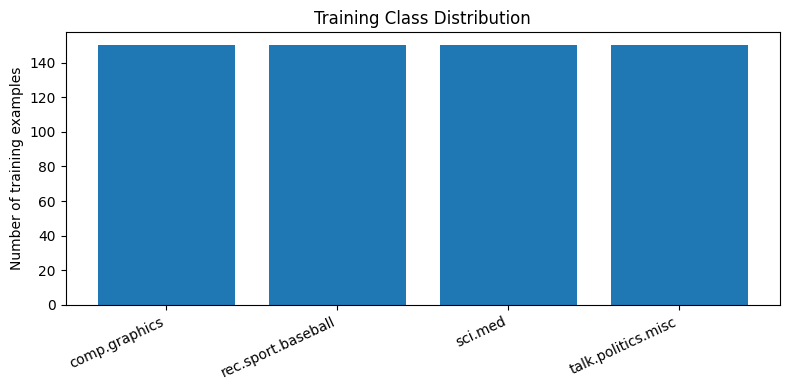

In [5]:
# Class distribution plot
train_counts = pd.Series(y_train).value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar([target_names[i] for i in train_counts.index], train_counts.values)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Number of training examples")
plt.title("Training Class Distribution")
plt.tight_layout()
plt.show()

# Baseline: TF-IDF + Logistic Regression

A paper implementation should include baselines. Before using a Transformer, we create a classical ML baseline.

This gives our project a useful comparison point:

```text
If the tiny GPT model performs poorly, the issue may be small data, small model size, short training, or word-level tokenization.
```

In [6]:
# ============================================================
# 2. Classical baseline: TF-IDF + Logistic Regression
# ============================================================

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])

baseline.fit(train_texts, y_train)
baseline_pred = baseline.predict(test_texts)
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, average="macro")

print(f"TF-IDF + Logistic Regression accuracy: {baseline_acc:.4f}")
print(f"TF-IDF + Logistic Regression macro-F1: {baseline_f1:.4f}")

TF-IDF + Logistic Regression accuracy: 0.8406
TF-IDF + Logistic Regression macro-F1: 0.8410


# Build a Simple Tokenizer

The paper used BPE tokenization. For learning clarity, our notebook uses a simple word-level tokenizer.

Special tokens:

| Token | Meaning |
|---|---|
| `<pad>` | Padding |
| `<unk>` | Unknown token |
| `<bos>` | Beginning of sequence |
| `<eos>` | End of sequence |
| `<sep>` | Separator token |

The model receives token IDs, not raw strings.

In [7]:
# ============================================================
# 3. Simple word-level tokenizer
# ============================================================

class SimpleWordTokenizer:
    def __init__(self, max_vocab_size=12000, min_freq=1):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.special_tokens = ["<pad>", "<unk>", "<bos>", "<eos>", "<sep>"]
        self.token_to_id = {}
        self.id_to_token = {}

    @staticmethod
    def tokenize(text):
        text = text.lower()
        return re.findall(r"[a-z]+(?:'[a-z]+)?|[0-9]+|[^\sA-Za-z0-9]", text)

    def fit(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(self.tokenize(text))
        vocab = list(self.special_tokens)
        for token, freq in counter.most_common(self.max_vocab_size - len(self.special_tokens)):
            if freq >= self.min_freq and token not in self.special_tokens:
                vocab.append(token)
        self.token_to_id = {tok: idx for idx, tok in enumerate(vocab)}
        self.id_to_token = {idx: tok for tok, idx in self.token_to_id.items()}
        return self

    @property
    def pad_id(self):
        return self.token_to_id["<pad>"]

    @property
    def unk_id(self):
        return self.token_to_id["<unk>"]

    @property
    def bos_id(self):
        return self.token_to_id["<bos>"]

    @property
    def eos_id(self):
        return self.token_to_id["<eos>"]

    @property
    def sep_id(self):
        return self.token_to_id["<sep>"]

    def encode(self, text, max_len=None, add_bos=True, add_eos=True):
        ids = []
        if add_bos:
            ids.append(self.bos_id)
        ids.extend(self.token_to_id.get(tok, self.unk_id) for tok in self.tokenize(text))
        if add_eos:
            ids.append(self.eos_id)
        if max_len is not None:
            ids = ids[:max_len]
            if add_eos and len(ids) > 0:
                ids[-1] = self.eos_id
        return ids

    def decode(self, ids, skip_special=True):
        tokens = []
        for idx in ids:
            tok = self.id_to_token.get(int(idx), "<unk>")
            if skip_special and tok in self.special_tokens:
                continue
            tokens.append(tok)
        return " ".join(tokens)

    def __len__(self):
        return len(self.token_to_id)


tokenizer = SimpleWordTokenizer(max_vocab_size=8000 if QUICK_RUN else 15000, min_freq=1)
tokenizer.fit(train_texts)

print("Vocabulary size:", len(tokenizer))
print("Example tokens:", tokenizer.tokenize(train_texts[0])[:30])
print("Example ids:", tokenizer.encode(train_texts[0], max_len=20))

Vocabulary size: 8000
Example tokens: ['the', 'speculum', 'is', 'the', 'little', 'cone', 'that', 'fits', 'on', 'the', 'end', 'of', 'the', 'otoscope', '.', 'there', 'are', 'also', 'vaginal', 'specula', 'that', 'females', 'and', 'gynecologists', 'are', 'all', 'too', 'familiar', 'with', '.']
Example ids: [2, 7, 6748, 15, 7, 303, 3624, 13, 1422, 27, 7, 357, 10, 7, 6749, 5, 51, 30, 101, 3]


# Build Language Modeling and Classification Datasets

## Language modeling data

For next-token prediction:

```text
Input:  [x1, x2, x3, ..., x(t-1)]
Target: [x2, x3, x4, ..., xt]
```

## Classification data

For text classification:

```text
Input:  [<bos>, text tokens, <eos>]
Target: class label
```

In [8]:
# ============================================================
# 4. PyTorch datasets and dataloaders
# ============================================================

class LanguageModelingDataset(Dataset):
    def __init__(self, texts, tokenizer, block_size=64, stride=32, max_sequences=3000):
        self.block_size = block_size
        all_ids = []
        for text in texts:
            ids = tokenizer.encode(text, max_len=256, add_bos=True, add_eos=True)
            all_ids.extend(ids + [tokenizer.sep_id])

        if len(all_ids) < block_size + 2:
            all_ids = all_ids * math.ceil((block_size + 2) / max(1, len(all_ids)))

        self.examples = []
        pos = 0
        while pos + block_size + 1 <= len(all_ids) and len(self.examples) < max_sequences:
            chunk = torch.tensor(all_ids[pos:pos + block_size + 1], dtype=torch.long)
            self.examples.append(chunk)
            pos += stride

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        chunk = self.examples[idx]
        return chunk[:-1], chunk[1:]


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = self.tokenizer.encode(self.texts[idx], max_len=self.max_len, add_bos=True, add_eos=True)
        return torch.tensor(ids, dtype=torch.long), int(self.labels[idx])


def collate_classification(batch, pad_id):
    ids, labels = zip(*batch)
    max_len = max(len(x) for x in ids)
    x = torch.full((len(ids), max_len), pad_id, dtype=torch.long)
    for i, seq in enumerate(ids):
        x[i, :len(seq)] = seq
    attention_mask = (x != pad_id).long()
    y = torch.tensor(labels, dtype=torch.long)
    return x, attention_mask, y


BLOCK_SIZE = 64 if QUICK_RUN else 128
CLASS_MAX_LEN = 96 if QUICK_RUN else 160
BATCH_SIZE = 32

lm_dataset = LanguageModelingDataset(
    train_texts,
    tokenizer,
    block_size=BLOCK_SIZE,
    stride=BLOCK_SIZE // 2,
    max_sequences=1200 if QUICK_RUN else 8000,
)

train_cls_dataset = TextClassificationDataset(train_texts, y_train, tokenizer, max_len=CLASS_MAX_LEN)
test_cls_dataset = TextClassificationDataset(test_texts, y_test, tokenizer, max_len=CLASS_MAX_LEN)

lm_loader = DataLoader(lm_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_cls_loader = DataLoader(
    train_cls_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda batch: collate_classification(batch, tokenizer.pad_id),
)
test_cls_loader = DataLoader(
    test_cls_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda batch: collate_classification(batch, tokenizer.pad_id),
)

print("LM sequences:", len(lm_dataset))
print("Classification train examples:", len(train_cls_dataset))
print("Classification test examples:", len(test_cls_dataset))

x_lm, y_lm = next(iter(lm_loader))
print("LM batch x:", x_lm.shape, "LM batch y:", y_lm.shape)

x_cls, mask_cls, y_cls = next(iter(train_cls_loader))
print("CLS batch x:", x_cls.shape, "mask:", mask_cls.shape, "labels:", y_cls.shape)

LM sequences: 1200
Classification train examples: 600
Classification test examples: 320
LM batch x: torch.Size([32, 64]) LM batch y: torch.Size([32, 64])
CLS batch x: torch.Size([32, 96]) mask: torch.Size([32, 96]) labels: torch.Size([32])


# GPT-Style Decoder-Only Transformer from Scratch

The core of GPT is a stack of Transformer decoder blocks.

Each block contains:

```text
Input hidden states
   ↓
LayerNorm
   ↓
Masked Multi-Head Self-Attention
   ↓
Residual connection
   ↓
LayerNorm
   ↓
MLP / Feed Forward Network with GELU
   ↓
Residual connection
```

We implement the model with Python OOP classes:

- `GPTConfig`
- `CausalSelfAttention`
- `GPTMLP`
- `GPTBlock`
- `GPTBackbone`
- `GPTLanguageModel`
- `GPTForClassificationWithAuxLM`

In [9]:
# ============================================================
# 5. GPT-style model implementation
# ============================================================

@dataclass
class GPTConfig:
    vocab_size: int
    block_size: int
    n_class: int
    n_layer: int = 2
    n_head: int = 4
    n_embd: int = 96
    dropout: float = 0.1
    pad_token_id: int = 0


class CausalSelfAttention(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.n_embd % config.n_head == 0, "n_embd must be divisible by n_head"
        self.n_head = config.n_head
        self.head_dim = config.n_embd // config.n_head
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)

    def forward(self, x, attention_mask=None):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=2)

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # B, H, T, D
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)  # B, H, T, T

        # Causal mask: each token can only attend to itself and previous tokens.
        causal_mask = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        scores = scores.masked_fill(~causal_mask.view(1, 1, T, T), float("-inf"))

        # Padding mask: ignore padded keys.
        if attention_mask is not None:
            key_mask = attention_mask.to(torch.bool).view(B, 1, 1, T)
            scores = scores.masked_fill(~key_mask, float("-inf"))

        att = F.softmax(scores, dim=-1)
        att = torch.nan_to_num(att, nan=0.0)
        att = self.attn_dropout(att)

        y = att @ v  # B, H, T, D
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y


class GPTMLP(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


class GPTBlock(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = GPTMLP(config)

    def forward(self, x, attention_mask=None):
        x = x + self.attn(self.ln_1(x), attention_mask=attention_mask)
        x = x + self.mlp(self.ln_2(x))
        return x


class GPTBackbone(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.drop = nn.Dropout(config.dropout)
        self.blocks = nn.ModuleList([GPTBlock(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, input_ids, attention_mask=None):
        B, T = input_ids.shape
        if T > self.config.block_size:
            input_ids = input_ids[:, -self.config.block_size:]
            if attention_mask is not None:
                attention_mask = attention_mask[:, -self.config.block_size:]
            T = self.config.block_size

        positions = torch.arange(0, T, device=input_ids.device).unsqueeze(0)
        x = self.tok_emb(input_ids) + self.pos_emb(positions)
        x = self.drop(x)

        for block in self.blocks:
            x = block(x, attention_mask=attention_mask)
        x = self.ln_f(x)
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.backbone = GPTBackbone(config)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        # Weight tying: output embedding matrix shares weights with token embedding matrix.
        self.lm_head.weight = self.backbone.tok_emb.weight

    def forward(self, input_ids, labels=None, attention_mask=None):
        h = self.backbone(input_ids, attention_mask=attention_mask)
        logits = self.lm_head(h)
        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1),
                ignore_index=self.config.pad_token_id,
            )
        return {"logits": logits, "loss": loss, "hidden_states": h}


class GPTForClassificationWithAuxLM(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.backbone = GPTBackbone(config)
        self.dropout = nn.Dropout(config.dropout)
        self.classifier = nn.Linear(config.n_embd, config.n_class)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.lm_head.weight = self.backbone.tok_emb.weight

    def forward(self, input_ids, attention_mask=None, labels=None, aux_lm_lambda=0.0):
        B, T_input = input_ids.shape

        # The backbone itself handles truncation to self.config.block_size
        h = self.backbone(input_ids, attention_mask=attention_mask)
        # T_processed will be self.config.block_size
        _, T_processed, C = h.shape

        # Truncate input_ids and attention_mask to match the processed length for downstream uses
        if T_input > T_processed:
            input_ids_processed = input_ids[:, -T_processed:]
            if attention_mask is not None:
                attention_mask_processed = attention_mask[:, -T_processed:]
            else:
                # If original attention_mask was None, and input was truncated,
                # create a full mask for the processed input.
                attention_mask_processed = torch.ones(B, T_processed, device=input_ids.device, dtype=torch.long)
        else:
            input_ids_processed = input_ids
            attention_mask_processed = attention_mask

        # Calculate last_index for pooling
        if attention_mask_processed is None:
            last_index = torch.full((B,), T_processed - 1, device=input_ids.device, dtype=torch.long)
        else:
            last_index = attention_mask_processed.sum(dim=1).sub(1).clamp(min=0).to(torch.long)

        pooled = h[torch.arange(B, device=input_ids.device), last_index]
        logits = self.classifier(self.dropout(pooled))

        cls_loss = None
        lm_loss = None
        total_loss = None

        if labels is not None:
            cls_loss = F.cross_entropy(logits, labels)
            total_loss = cls_loss

            if aux_lm_lambda > 0:
                # For LM loss, use processed input_ids and attention_mask
                lm_logits = self.lm_head(h[:, :-1, :])
                lm_targets = input_ids_processed[:, 1:].clone()
                if attention_mask_processed is not None:
                    lm_targets[attention_mask_processed[:, 1:] == 0] = -100
                lm_loss = F.cross_entropy(
                    lm_logits.reshape(-1, lm_logits.size(-1)),
                    lm_targets.reshape(-1),
                    ignore_index=-100,
                )
                total_loss = cls_loss + aux_lm_lambda * lm_loss

        return {
            "logits": logits,
            "loss": total_loss,
            "cls_loss": cls_loss,
            "lm_loss": lm_loss,
            "hidden_states": h,
        }

In [10]:
# ============================================================
# 6. Smoke test: verify tensor shapes and loss computation
# ============================================================

smoke_config = GPTConfig(
    vocab_size=len(tokenizer),
    block_size=BLOCK_SIZE,
    n_class=len(target_names),
    n_layer=1,
    n_head=2,
    n_embd=64,
    dropout=0.1,
    pad_token_id=tokenizer.pad_id,
)

smoke_lm = GPTLanguageModel(smoke_config)
x = torch.randint(0, len(tokenizer), (2, BLOCK_SIZE))
y = torch.randint(0, len(tokenizer), (2, BLOCK_SIZE))
out = smoke_lm(x, labels=y)
print("LM logits shape:", out["logits"].shape)
print("LM loss:", float(out["loss"]))

smoke_cls = GPTForClassificationWithAuxLM(smoke_config)
mask = torch.ones_like(x)
labels = torch.tensor([0, 1])
out = smoke_cls(x, attention_mask=mask, labels=labels, aux_lm_lambda=0.1)
print("CLS logits shape:", out["logits"].shape)
print("Total loss:", float(out["loss"]))

LM logits shape: torch.Size([2, 64, 8000])
LM loss: 8.974966049194336
CLS logits shape: torch.Size([2, 4])
Total loss: 2.223707675933838


/tmp/ipykernel_21902/1651174003.py:21: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("LM loss:", float(out["loss"]))


# Pre-train Tiny GPT with Language Modeling

This is the small version of Equation 1.

```text
For each sequence:
Input  = tokens except the last token
Target = tokens except the first token
```

The model learns to predict the next token.

In [11]:
# ============================================================
# 7. Language-model pre-training utilities
# ============================================================

def train_lm(model, loader, optimizer, epochs=1, pad_id=0, grad_clip=1.0):
    model.train()
    history = []
    for epoch in range(1, epochs + 1):
        start = time.time()
        total_loss = 0.0
        total_tokens = 0
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            attention_mask = (x != pad_id).long()

            optimizer.zero_grad(set_to_none=True)
            out = model(x, labels=y, attention_mask=attention_mask)
            loss = out["loss"]
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            n_tokens = y.numel()
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens

        avg_loss = total_loss / max(1, total_tokens)
        ppl = math.exp(min(avg_loss, 20))
        history.append({"epoch": epoch, "lm_loss": avg_loss, "perplexity": ppl})
        print(f"LM epoch {epoch}: loss={avg_loss:.4f}, ppl={ppl:.2f}, time={time.time() - start:.1f}s")
    return pd.DataFrame(history)


config = GPTConfig(
    vocab_size=len(tokenizer),
    block_size=BLOCK_SIZE,
    n_class=len(target_names),
    n_layer=2 if QUICK_RUN else 4,
    n_head=4,
    n_embd=96 if QUICK_RUN else 192,
    dropout=0.1,
    pad_token_id=tokenizer.pad_id,
)

lm_model = GPTLanguageModel(config).to(device)
optimizer = torch.optim.AdamW(lm_model.parameters(), lr=3e-4, weight_decay=0.01)

print(lm_model)
print("Number of parameters:", sum(p.numel() for p in lm_model.parameters()) / 1e6, "M")

GPTLanguageModel(
  (backbone): GPTBackbone(
    (tok_emb): Embedding(8000, 96)
    (pos_emb): Embedding(64, 96)
    (drop): Dropout(p=0.1, inplace=False)
    (blocks): ModuleList(
      (0-1): 2 x GPTBlock(
        (ln_1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=96, out_features=288, bias=True)
          (c_proj): Linear(in_features=96, out_features=96, bias=True)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTMLP(
          (net): Sequential(
            (0): Linear(in_features=96, out_features=384, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=384, out_features=96, bias=True)
            (3): Dropout(p=0.1, inplace=False)
          )
        )
      )
    )
    (ln_f): LayerNorm((96,), eps=1e-

In [12]:
# Run pre-training
# For better results, increase LM_EPOCHS and turn QUICK_RUN=False near the top.
LM_EPOCHS = 1 if QUICK_RUN else 5
lm_history = train_lm(lm_model, lm_loader, optimizer, epochs=LM_EPOCHS, pad_id=tokenizer.pad_id)
lm_history

LM epoch 1: loss=8.3273, ppl=4135.06, time=20.1s


,epoch,lm_loss,perplexity
0,1,8.327256,4135.05648


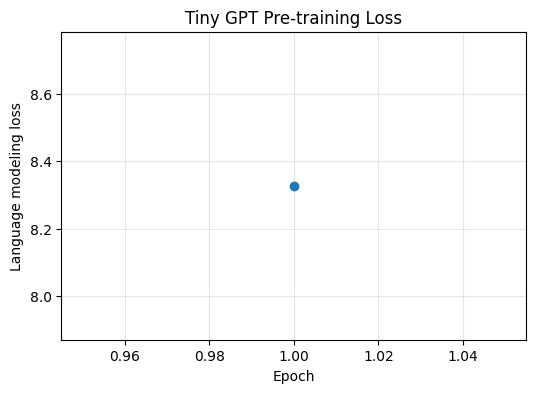

In [13]:
# Plot LM pre-training loss
plt.figure(figsize=(6, 4))
plt.plot(lm_history["epoch"], lm_history["lm_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Language modeling loss")
plt.title("Tiny GPT Pre-training Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Optional generation check
@torch.no_grad()
def generate_text(model, tokenizer, prompt, max_new_tokens=40, temperature=0.9):
    model.eval()
    ids = tokenizer.encode(prompt, max_len=model.config.block_size, add_bos=True, add_eos=False)
    x = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        x_cond = x[:, -model.config.block_size:]
        attention_mask = (x_cond != tokenizer.pad_id).long()
        logits = model(x_cond, attention_mask=attention_mask)["logits"][:, -1, :]
        logits = logits / max(temperature, 1e-6)
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        x = torch.cat([x, next_id], dim=1)
    return tokenizer.decode(x[0].tolist(), skip_special=True)

print(generate_text(lm_model, tokenizer, "the team", max_new_tokens=30))

the team all developing 536 mouths tolerate specified permission 389 mostly steel figures toronto phrase antibiotic contributed of compatables a's richardson polygons applied * cub bunch that florida byteswap slide thoughts arms


# Fine-tune GPT for Text Classification

Now we attach a classifier head and fine-tune the pre-trained Transformer.

This implements Equation 3 and Equation 4.

We also include the auxiliary LM loss from Equation 5:

```text
total_loss = classification_loss + λ × language_modeling_loss
```

In the original paper, `λ = 0.5`. In our tiny project, a smaller value can be more stable, so we use `0.05` by default.

In [15]:
# ============================================================
# 8. Classification training and evaluation utilities
# ============================================================

def train_classifier(model, loader, optimizer, epochs=3, aux_lm_lambda=0.05, grad_clip=1.0):
    model.train()
    history = []
    for epoch in range(1, epochs + 1):
        start = time.time()
        total_loss = 0.0
        total_cls_loss = 0.0
        total_lm_loss = 0.0
        total_examples = 0

        for input_ids, attention_mask, labels in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            out = model(
                input_ids,
                attention_mask=attention_mask,
                labels=labels,
                aux_lm_lambda=aux_lm_lambda,
            )
            loss = out["loss"]
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            batch_size = labels.size(0)
            total_examples += batch_size
            total_loss += out["loss"].item() * batch_size
            total_cls_loss += out["cls_loss"].item() * batch_size
            if out["lm_loss"] is not None:
                total_lm_loss += out["lm_loss"].item() * batch_size

        row = {
            "epoch": epoch,
            "total_loss": total_loss / max(1, total_examples),
            "cls_loss": total_cls_loss / max(1, total_examples),
            "aux_lm_loss": total_lm_loss / max(1, total_examples),
        }
        history.append(row)
        print(
            f"CLS epoch {epoch}: total={row['total_loss']:.4f}, "
            f"cls={row['cls_loss']:.4f}, aux_lm={row['aux_lm_loss']:.4f}, "
            f"time={time.time() - start:.1f}s"
        )
    return pd.DataFrame(history)


@torch.no_grad()
def evaluate_classifier(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    for input_ids, attention_mask, labels in loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        out = model(input_ids, attention_mask=attention_mask)
        preds = out["logits"].argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return acc, macro_f1, np.array(all_labels), np.array(all_preds)

In [16]:
clf_model = GPTForClassificationWithAuxLM(config).to(device)
clf_model.backbone.load_state_dict(copy.deepcopy(lm_model.backbone.state_dict()))

clf_optimizer = torch.optim.AdamW(clf_model.parameters(), lr=5e-4 if QUICK_RUN else 2e-4, weight_decay=0.01)

CLS_EPOCHS = 2 if QUICK_RUN else 6
AUX_LM_LAMBDA = 0.05

cls_history = train_classifier(
    clf_model,
    train_cls_loader,
    clf_optimizer,
    epochs=CLS_EPOCHS,
    aux_lm_lambda=AUX_LM_LAMBDA,
)

cls_history

CLS epoch 1: total=1.8046, cls=1.4300, aux_lm=7.4935, time=10.7s
CLS epoch 2: total=1.7050, cls=1.3520, aux_lm=7.0586, time=10.8s


,epoch,total_loss,cls_loss,aux_lm_loss
0,1,1.804640,1.429967,7.493454
1,2,1.704954,1.352026,7.058553


In [17]:
# Evaluate fine-tuned GPT classifier
pretrained_acc, pretrained_f1, y_true, y_pred = evaluate_classifier(clf_model, test_cls_loader)
print(f"Pre-trained tiny GPT fine-tuned accuracy: {pretrained_acc:.4f}")
print(f"Pre-trained tiny GPT fine-tuned macro-F1: {pretrained_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

Pre-trained tiny GPT fine-tuned accuracy: 0.3375
Pre-trained tiny GPT fine-tuned macro-F1: 0.2849

                    precision    recall  f1-score   support

     comp.graphics       0.57      0.47      0.52        80
rec.sport.baseball       0.28      0.16      0.21        80
           sci.med       0.27      0.70      0.39        80
talk.politics.misc       1.00      0.01      0.02        80

          accuracy                           0.34       320
         macro avg       0.53      0.34      0.28       320
      weighted avg       0.53      0.34      0.28       320



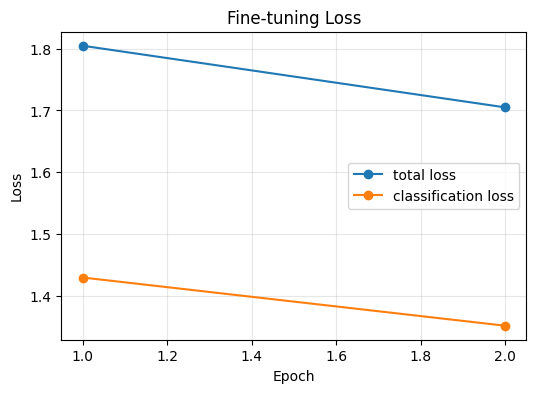

In [18]:
# Plot classification training loss
plt.figure(figsize=(6, 4))
plt.plot(cls_history["epoch"], cls_history["total_loss"], marker="o", label="total loss")
plt.plot(cls_history["epoch"], cls_history["cls_loss"], marker="o", label="classification loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-tuning Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

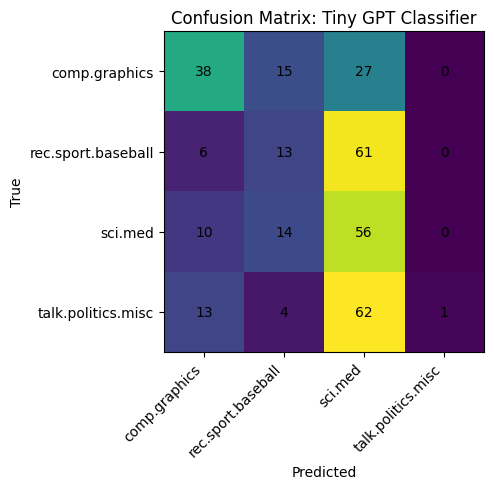

In [19]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix: Tiny GPT Classifier")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(target_names)), target_names, rotation=45, ha="right")
plt.yticks(range(len(target_names)), target_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
plt.show()

# Optional Ablation: Random Init vs Pre-trained Init

The paper's most important ablation is **without pre-training**.

The following cell trains a classifier from random initialization. It may take extra time, so it is optional.

Expected lesson:

```text
Pre-training usually helps when the model, data, and training time are sufficient.
```

In this small notebook, results can vary because our model is tiny and training is short.

In [20]:
# Optional ablation: train from scratch instead of loading the LM-pretrained backbone.
RUN_RANDOM_INIT_ABLATION = False

if RUN_RANDOM_INIT_ABLATION:
    scratch_model = GPTForClassificationWithAuxLM(config).to(device)
    scratch_optimizer = torch.optim.AdamW(scratch_model.parameters(), lr=5e-4, weight_decay=0.01)
    scratch_history = train_classifier(
        scratch_model,
        train_cls_loader,
        scratch_optimizer,
        epochs=CLS_EPOCHS,
        aux_lm_lambda=AUX_LM_LAMBDA,
    )
    scratch_acc, scratch_f1, _, _ = evaluate_classifier(scratch_model, test_cls_loader)
    print(f"Scratch tiny GPT accuracy: {scratch_acc:.4f}")
    print(f"Scratch tiny GPT macro-F1: {scratch_f1:.4f}")
else:
    scratch_acc, scratch_f1 = np.nan, np.nan
    print("Random-init ablation skipped. Set RUN_RANDOM_INIT_ABLATION=True to run it.")

Random-init ablation skipped. Set RUN_RANDOM_INIT_ABLATION=True to run it.


In [21]:
# Compare project results
results = pd.DataFrame([
    {"model": "TF-IDF + Logistic Regression", "accuracy": baseline_acc, "macro_f1": baseline_f1},
    {"model": "Tiny GPT: pre-train + fine-tune", "accuracy": pretrained_acc, "macro_f1": pretrained_f1},
    {"model": "Tiny GPT: random init", "accuracy": scratch_acc, "macro_f1": scratch_f1},
])
results

,model,accuracy,macro_f1
0,TF-IDF + Logistic Regression,0.840625,0.841032
1,Tiny GPT: pre-train + fine-tune,0.337500,0.284914
2,Tiny GPT: random init,NaN,NaN


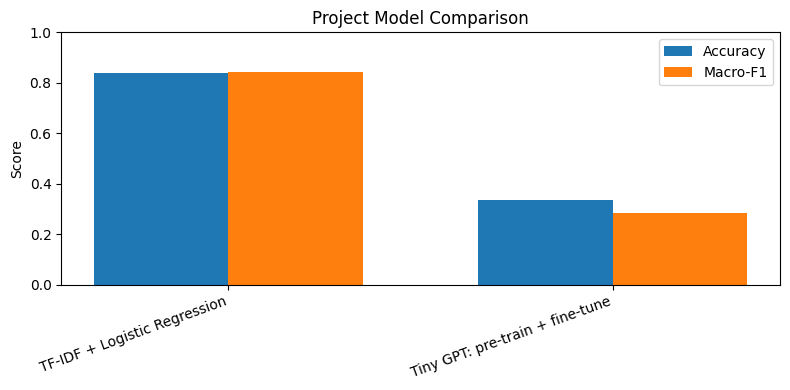

In [22]:
# Bar chart comparison
plot_df = results.dropna()
plt.figure(figsize=(8, 4))
positions = np.arange(len(plot_df))
width = 0.35
plt.bar(positions - width/2, plot_df["accuracy"], width, label="Accuracy")
plt.bar(positions + width/2, plot_df["macro_f1"], width, label="Macro-F1")
plt.xticks(positions, plot_df["model"], rotation=20, ha="right")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Project Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Predict on New Text

This cell shows how the fine-tuned model can classify new examples.

In [23]:
@torch.no_grad()
def predict_text(model, tokenizer, text, target_names, max_len=CLASS_MAX_LEN):
    model.eval()
    ids = tokenizer.encode(text, max_len=max_len, add_bos=True, add_eos=True)
    input_ids = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
    attention_mask = (input_ids != tokenizer.pad_id).long()
    out = model(input_ids, attention_mask=attention_mask)
    probs = F.softmax(out["logits"], dim=-1).squeeze(0).cpu().numpy()
    pred_id = int(probs.argmax())
    return target_names[pred_id], probs

examples = [
    "The pitcher won the game after nine innings and the team celebrated.",
    "The doctor discussed treatment, symptoms, diagnosis, and patient recovery.",
    "The graphics rendering pipeline uses textures, pixels, and shaders.",
    "The election campaign focused on policy, tax reform, and government debate.",
]

for text in examples:
    label, probs = predict_text(clf_model, tokenizer, text, target_names)
    print("Text:", text)
    print("Predicted:", label)
    print("Probabilities:", dict(zip(target_names, np.round(probs, 3))))
    print("-" * 80)

Text: The pitcher won the game after nine innings and the team celebrated.
Predicted: rec.sport.baseball
Probabilities: {'comp.graphics': np.float32(0.094), 'rec.sport.baseball': np.float32(0.435), 'sci.med': np.float32(0.417), 'talk.politics.misc': np.float32(0.053)}
--------------------------------------------------------------------------------
Text: The doctor discussed treatment, symptoms, diagnosis, and patient recovery.
Predicted: rec.sport.baseball
Probabilities: {'comp.graphics': np.float32(0.209), 'rec.sport.baseball': np.float32(0.361), 'sci.med': np.float32(0.334), 'talk.politics.misc': np.float32(0.095)}
--------------------------------------------------------------------------------
Text: The graphics rendering pipeline uses textures, pixels, and shaders.
Predicted: comp.graphics
Probabilities: {'comp.graphics': np.float32(0.538), 'rec.sport.baseball': np.float32(0.171), 'sci.med': np.float32(0.142), 'talk.politics.misc': np.float32(0.149)}
-------------------------------

# Interview-Ready Explanation

## One-sentence summary

GPT-1 showed that a decoder-only Transformer can be generatively pre-trained on large unlabeled text and then fine-tuned with minimal architectural changes to perform many language understanding tasks.

## Why GPT-1 was influential

It helped establish the modern pre-training + fine-tuning paradigm for NLP.

## Why the model is decoder-only

The model is trained with a left-to-right language-modeling objective. Masked self-attention prevents each position from seeing future tokens.

## Why pre-training helps

Pre-training lets the model learn reusable language representations before seeing small supervised datasets.

## Why input transformations matter

Many NLP tasks are structured. GPT-1 converts them into token sequences so the same model architecture can process them.

## What is transferred during fine-tuning?

The Transformer parameters learned during language modeling are reused. Only a small task-specific output layer is added.

## Why learned position embeddings?

The paper used learned position embeddings instead of sinusoidal embeddings, allowing the model to learn position representations directly from data.

## What is the biggest limitation?

GPT-1 is left-to-right and cannot directly use future context while building representations. This is one reason later bidirectional pre-training methods became strong for understanding tasks.

# Paper-to-Code Mapping

| Paper concept | Notebook implementation |
|---|---|
| Unlabeled text corpus `U` | `train_texts` from 20 Newsgroups |
| Tokenization / BPE | `SimpleWordTokenizer` word tokenizer |
| Context window `k` | `BLOCK_SIZE` |
| Token embedding `We` | `self.tok_emb` |
| Position embedding `Wp` | `self.pos_emb` |
| Transformer decoder block | `GPTBlock` |
| Masked self-attention | `CausalSelfAttention` |
| LM objective `L1` | `GPTLanguageModel` + `train_lm` |
| Supervised objective `L2` | `GPTForClassificationWithAuxLM` classification loss |
| Auxiliary LM loss `λL1` | `aux_lm_lambda` in fine-tuning |
| Downstream classifier | `self.classifier` |
| Baseline comparison | TF-IDF + Logistic Regression |
| Ablation without pre-training | Optional random-init classifier |

# Final Research Notes: Gaps and Future Working

## Research gaps from a modern view

1. **Data scaling law not studied deeply**  
   The paper shows strong results, but it does not fully analyze how performance scales with model size, data size, and compute.

2. **Limited pre-training corpus diversity**  
   BooksCorpus gives long context, but it is not enough for broad factual and domain coverage.

3. **No instruction-following stage**  
   The model is not instruction-tuned. It learns language modeling and supervised task fine-tuning, not general instruction response.

4. **No retrieval mechanism**  
   The model must rely on parameters. It cannot search external documents for updated or domain-specific facts.

5. **Limited context window**  
   Long documents remain difficult.

6. **Bias and safety not central**  
   The paper predates many later concerns around bias, toxicity, privacy, and safe deployment.

7. **Understanding vs generation tension**  
   A left-to-right model is natural for generation, but some understanding tasks benefit from bidirectional context.

## Future working ideas

- Compare decoder-only GPT with encoder-only BERT on the same text-classification data.
- Replace word tokenizer with BPE or SentencePiece.
- Use larger context windows and observe effect.
- Add multi-task fine-tuning.
- Add parameter-efficient fine-tuning such as adapters or LoRA.
- Use retrieval-augmented fine-tuning for domain knowledge.
- Train on a domain corpus, then fine-tune on domain classification.
- Study how each layer contributes by freezing/unfreezing layers.
- Visualize attention heads to inspect learned behavior.

## Practical takeaway

GPT-1's core idea is not only a model architecture. It is a training strategy:

```text
Learn general language first.
Then adapt that knowledge to specific tasks.
```

That principle still drives modern NLP and LLM development.